<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import the required modules

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import pandas as pd
import numpy as np
import pickle
import sklearn.ensemble as ske
from sklearn import tree, linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
import joblib
from sklearn.metrics import confusion_matrix , accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

## 1. Getting our dataset ready to be used
Two main things:
   1. Split the data into features and label ( `X` & `y`)
   2. Removing non-numerical values .

In [ ]:
!gdown --fuzzy https://drive.google.com/file/d/1aMiZVj_QvfXgiXSpD3bQ2MaSZwul-n0g/view?usp=drive_link
!unzip /content/malware.csv.zip

Downloading...
From: https://drive.google.com/uc?id=1aMiZVj_QvfXgiXSpD3bQ2MaSZwul-n0g
To: /content/malware.csv.zip
100% 12.1M/12.1M [00:00<00:00, 28.0MB/s]
Archive:  /content/malware.csv.zip
  inflating: malware.csv             


In [ ]:
data = pd.read_csv('/content/malware.csv', sep='|')
X = data.drop(['Name', 'md5', 'legitimate'], axis=1).values
y = data['legitimate'].values


# Display the features

## Feature engineering
* Lasso regression is used to simplify the features and reduce the parameters based on regression coefficient
* Parameter alpha determines the amount of simplification of features for our usage
* Using Meta-transformer( `SelectFromModel` ) for selecting features based on importance weights.
* Use `train_test_split` method to split into testing and training data
* Store the important features and print the features


In [ ]:
from numpy.random import seed
seed(1)
regressor = linear_model.Lasso(alpha= 0.05,
                               positive=True,
                               fit_intercept=True,
                               max_iter=1000,
                               tol=0.0001).fit(X,y)

m1 = SelectFromModel(regressor, prefit=True)

X_1 = m1.transform(X)
nb_features = X_1.shape[1]

print('%i features identified as important:' % nb_features)

X_train, X_test, y_train, y_test = train_test_split(X_1, y ,test_size=0.2)
features=[]
indices1 = np.argsort(regressor.coef_)[::-1][:nb_features]
importance=[]
for f in range(nb_features):
    print("%d. feature %s (%f)" % (f + 1, data.columns[2+indices1[f]], regressor.coef_[indices1[f]]))

for f in sorted(np.argsort(regressor.coef_)[::-1][:nb_features]):
    features.append(data.columns[2+f])
    importance.append(regressor.coef_[f])

11 features identified as important:
1. feature Subsystem (0.046186)
2. feature ResourcesMinEntropy (0.044549)
3. feature VersionInformationSize (0.014864)
4. feature MajorLinkerVersion (0.000896)
5. feature ImportsNbOrdinal (0.000896)
6. feature ExportNb (0.000136)
7. feature ResourcesNb (0.000106)
8. feature FileAlignment (0.000040)
9. feature ImportsNb (0.000022)
10. feature Machine (0.000019)
11. feature MajorImageVersion (0.000016)


# Plot the features vs regressor coefficient graph

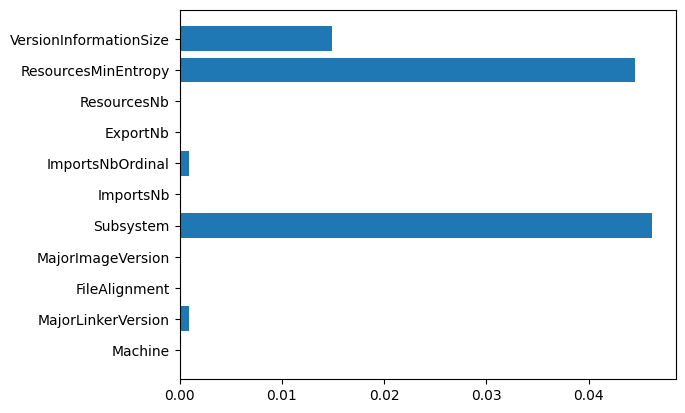

In [ ]:
from matplotlib import pyplot
pyplot.barh(features,importance)
pyplot.show()

# Training classifier model
* Iterate over various values of K to determine neighbours that are nearer and have similar densities or classes.
* Fit the training data over the classifier
* Predict on the test data
* Calculate the accuracy and store it in a array

In [ ]:
seed(1)
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics

s1 = []
y_predict=[]
ind=0
for i in range(5,100,5):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train,y_train)
    predict=knn.predict(X_test)
    y_predict.append(predict)
    s1.append(metrics.accuracy_score(y_test, predict))


# Plot the accuracy vs K value graph

Text(0, 0.5, 'Accuracy')

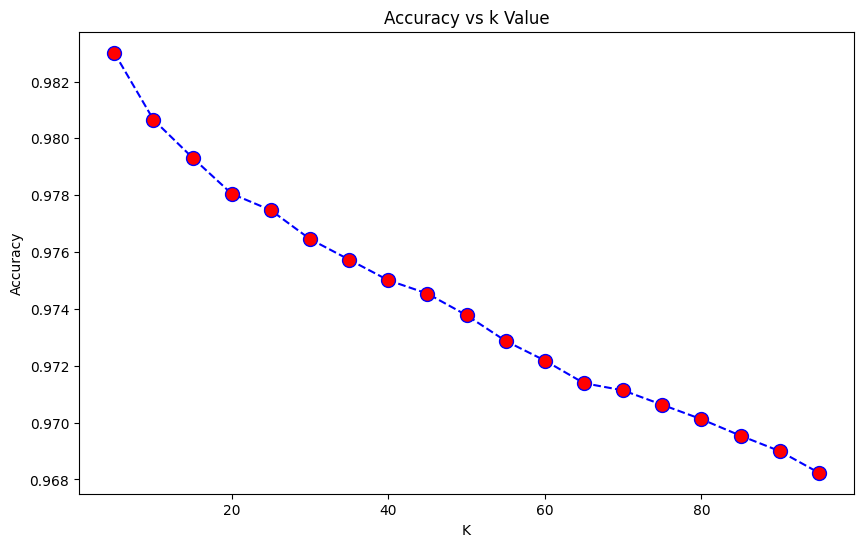

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(5,100,5), s1, color = 'blue', linestyle = 'dashed', marker = 'o', markerfacecolor = 'red', markersize = 10)
plt.title('Accuracy vs k Value')
plt.xlabel('K')
plt.ylabel('Accuracy')

In [ ]:
y_mx_predict=y_predict[s1.index(max(s1))]
y_mx_predict

array([0, 0, 0, ..., 0, 0, 1])

# Plot the confusion matrix

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def make_confusion_matrix(cf,
                          group_names=None,
                          categories='auto',
                          count=True,
                          percent=True,
                          cbar=True,
                          xyticks=True,
                          xyplotlabels=True,
                          sum_stats=True,
                          figsize=None,
                          cmap='Blues',
                          title=None):

    # CODE TO GENERATE TEXT INSIDE EACH SQUARE
    blanks = ['' for i in range(cf.size)]

    if group_names and len(group_names)==cf.size:
        group_labels = ["{}\n".format(value) for value in group_names]
    else:
        group_labels = blanks

    if count:
        group_counts = ["{0:0.0f}\n".format(value) for value in cf.flatten()]
    else:
        group_counts = blanks

    if percent:
        group_percentages = ["{0:.2%}".format(value) for value in cf.flatten()/np.sum(cf)]
    else:
        group_percentages = blanks

    box_labels = [f"{v1}{v2}{v3}".strip() for v1, v2, v3 in zip(group_labels,group_counts,group_percentages)]
    box_labels = np.asarray(box_labels).reshape(cf.shape[0],cf.shape[1])


    # CODE TO GENERATE SUMMARY STATISTICS & TEXT FOR SUMMARY STATS
    if sum_stats:
        #Accuracy is sum of diagonal divided by total observations
        accuracy  = np.trace(cf) / float(np.sum(cf))

        #if it is a binary confusion matrix, show some more stats
        if len(cf)==2:
            #Metrics for Binary Confusion Matrices
            precision = cf[1,1] / sum(cf[:,1])
            recall    = cf[1,1] / sum(cf[1,:])
            f1_score  = 2*precision*recall / (precision + recall)
            stats_text = "\n\nAccuracy={:0.3f}\nPrecision={:0.3f}\nRecall={:0.3f}\nF1 Score={:0.3f}".format(
                accuracy,precision,recall,f1_score)
        else:
            stats_text = "\n\nAccuracy={:0.3f}".format(accuracy)
    else:
        stats_text = ""


    # SET FIGURE PARAMETERS ACCORDING TO OTHER ARGUMENTS
    if figsize==None:
        #Get default figure size if not set
        figsize = plt.rcParams.get('figure.figsize')

    if xyticks==False:
        #Do not show categories if xyticks is False
        categories=False


    # MAKE THE HEATMAP VISUALIZATION
    plt.figure(figsize=figsize)
    sns.heatmap(cf,annot=box_labels,fmt="",cmap=cmap,cbar=cbar,xticklabels=categories,yticklabels=categories)

    if xyplotlabels:
        plt.ylabel('True label')
        plt.xlabel('Predicted label' + stats_text)
    else:
        plt.xlabel(stats_text)

    if title:
        plt.title(title)

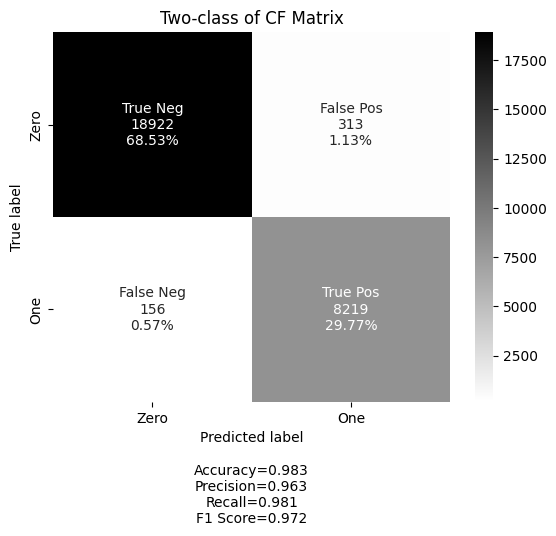

In [ ]:
cf_matrix=confusion_matrix(y_test,y_mx_predict)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Zero', 'One']
make_confusion_matrix(cf_matrix, group_names=labels, categories=categories, cmap='binary', title='Two-class of CF Matrix')

In [ ]:
def evaluate_preds(y_true, y_preds):
    accuracy = accuracy_score(y_true, y_preds)
    precision = precision_score(y_true, y_preds)
    recall = recall_score(y_true, y_preds)
    f1 = f1_score(y_true, y_preds)
    metric_dict = {"accuracy": accuracy*100,
                   "precision": precision*100,
                   "recall": recall*100,
                   "f1": f1*100}

    return metric_dict

In [ ]:
metrics1 = evaluate_preds(y_test, y_mx_predict)

# Import the required modules

In [ ]:
import pandas as pd
import numpy as np
import sklearn.ensemble as ske
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

## 1. Getting our dataset ready to be used
Two main things:
   1. Split the data into features and label ( `X` & `y`)
   2. Removing non-numerical values .

In [ ]:
data = pd.read_csv('/content/malware.csv', sep='|')
X = data.drop(['Name', 'md5', 'legitimate'], axis=1).values
y = data['legitimate'].values


# Display the features

## Feature engineering
* Gradient Boosting is used to simplify the features and reduce the parameters based on feature importance coefficient
* Gradient boosting method allocates feature importance using tree structure by assigning feature importances based on attributes.
* Using Meta-transformer( `SelectFromModel` ) for selecting features based on importance weights.
* the required feature importances are extracted using `transform` method and stored.
* Use `train_test_split` method to split into testing and training data
* Store the important features and print the features


In [ ]:
seed(1)
print('Researching important feature based on %i total features\n' % X.shape[1])
fsel = ske.GradientBoostingClassifier().fit(X, y)
model = SelectFromModel(fsel, prefit=True)
X_new = model.transform(X)
nb_features = X_new.shape[1]
X_train, X_test, y_train, y_test = train_test_split(X_new, y ,test_size=0.5)
features = []

Researching important feature based on 54 total features



In [ ]:
print('%i features identified as important:' % nb_features)

indices = np.argsort(fsel.feature_importances_)[::-1][:nb_features]

for f in range(nb_features):
    print("%d. feature %s (%f)" % (f + 1, data.columns[2+indices[f]], fsel.feature_importances_[indices[f]]))
importance=[]
# XXX : take care of the feature order
features=[]
for f in sorted(np.argsort(fsel.feature_importances_)[::-1][:nb_features]):
    features.append(data.columns[2+f])
    importance.append(fsel.feature_importances_[f])

4 features identified as important:
1. feature ImageBase (0.807033)
2. feature Subsystem (0.094048)
3. feature VersionInformationSize (0.029094)
4. feature MajorOperatingSystemVersion (0.020443)


# Plot the features vs feature importance graph

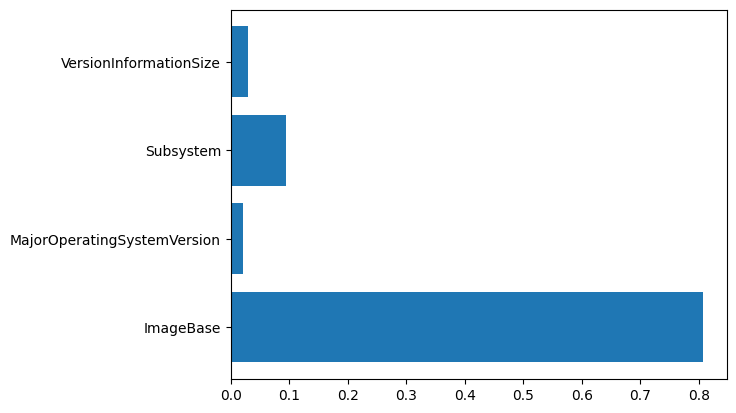

In [ ]:
from matplotlib import pyplot
pyplot.barh(features,importance)
pyplot.show()

# Import the Classifier module
* Use the XGB(Extreme Gradient boosting) Classifier to design gradient boosted tree structure to enhance speed and performance.
* Fit the training data over the classifier
* Predict on the test data
* Calculate the accuracy and store it in a array

In [ ]:
seed(1)
xgbc=XGBClassifier(n_estimators = 5, objective="binary:logistic", use_label_encoder=False,eval_metric='auc')
xgbc.fit(X_train,y_train)
xgbc_predict=xgbc.predict(X_test)
print(xgbc.score(X_test,y_test))

0.9855992118683357


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:25:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Display the confusion matrix

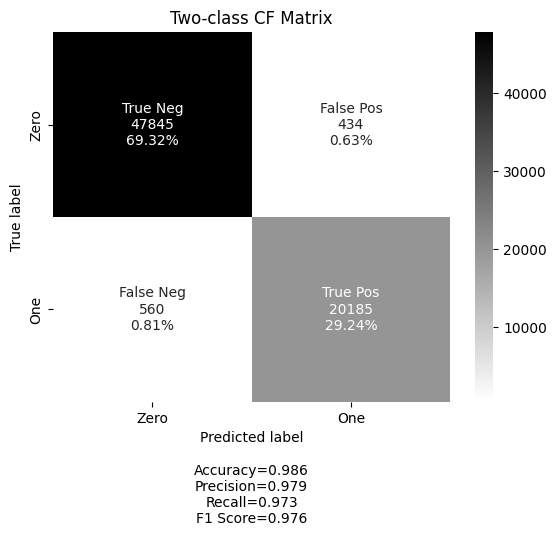

In [ ]:
cf_matrix=confusion_matrix(y_test,xgbc_predict)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Zero', 'One']
make_confusion_matrix(cf_matrix, group_names=labels, categories=categories, cmap='binary', title='Two-class CF Matrix')

In [ ]:
metrics2 = evaluate_preds(y_test, xgbc_predict)

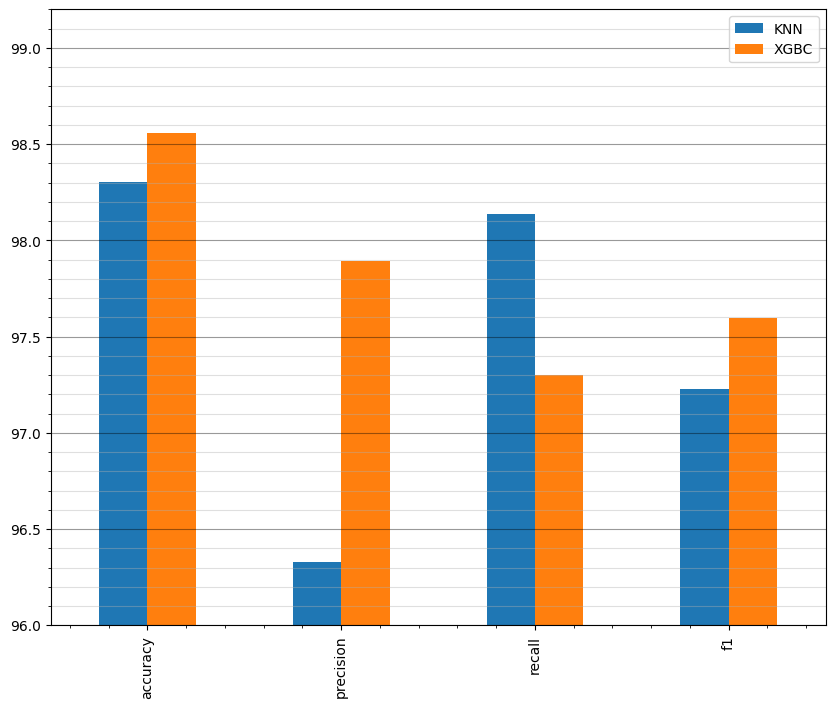

In [ ]:
compare_metrics = pd.DataFrame({"KNN": metrics1,
                                "XGBC": metrics2})

compare_metrics.plot.bar(figsize=(10, 8))
plt.ylim(96,99.2)
plt.yscale('linear')
plt.minorticks_on()
plt.grid(axis='y',which="minor",alpha=0.4)
plt.grid(axis='y',which="major",alpha=0.4,color="black")

In [ ]:
import os

print('Saving algorithm and feature list in classifier directory...')

# Define the algorithms dictionary with the trained models
# Assuming xgbc is the intended model to be saved based on context.
algorithms = {
    "XGBC": xgbc
}

# Determine the winner (explicitly setting to XGBC based on higher accuracy in compare_metrics
# and alignment with current `features` variable).
winner = "XGBC"

# Create the classifier directory if it doesn't exist
if not os.path.exists('classifier'):
    os.makedirs('classifier')

joblib.dump(algorithms[winner], 'classifier/classifier.pkl')
open('classifier/features.pkl', 'wb').write((pickle.dumps(features)))
a=pickle.dumps(features)
b=pickle.loads(a)
#print(b==a)
print('Saved')
print(features)

Saving algorithm and feature list in classifier directory...
Saved
['ImageBase', 'MajorOperatingSystemVersion', 'Subsystem', 'VersionInformationSize']


In [ ]:
import pandas as pd
import numpy as np
import sklearn.ensemble as ske
from sklearn import tree, linear_model
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectFromModel
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
import time

In [ ]:
data[["Machine" ,"SizeOfOptionalHeader" ,'SectionAlignment','FileAlignment', 'MajorOperatingSystemVersion'
                 ,'MinorOperatingSystemVersion','MajorSubsystemVersion', 'MinorSubsystemVersion', 'Subsystem', 'LoaderFlags'
                 ,'VersionInformationSize']]=data[["Machine" ,"SizeOfOptionalHeader" ,'SectionAlignment','FileAlignment', 'MajorOperatingSystemVersion'
                 ,'MinorOperatingSystemVersion','MajorSubsystemVersion', 'MinorSubsystemVersion', 'Subsystem', 'LoaderFlags'
                 ,'VersionInformationSize']].astype('str')
data.to_pickle('file.pkl')
data = pd.read_pickle('file.pkl')
X = data.drop(['Name', 'md5', 'legitimate'], axis=1)
y = data['legitimate']

In [ ]:
from numpy.random import seed
seed(1)
!pip install category_encoders
import category_encoders as ce
h = ce.HashingEncoder(cols=["Machine" ,"SizeOfOptionalHeader" ,
'SectionAlignment','FileAlignment', 'MajorOperatingSystemVersion'
                 ,'MinorOperatingSystemVersion',
                 'MajorSubsystemVersion', 'MinorSubsystemVersion', 'Subsystem', 'LoaderFlags'
                 ,'VersionInformationSize'])
f = h.fit_transform(X,y)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.0 MB/s eta 0:00:00


In [ ]:
X=f.values
y=y.values

In [ ]:
open('features.pkl', 'wb').write((pickle.dumps(f.keys())))

1112

In [ ]:
seed(1)
start_time = time.time()
print('Identifying important feature based on %i total features\n' % X.shape[1])

fsel = ske.ExtraTreesClassifier().fit(X, y)

model = SelectFromModel(fsel, prefit=True)
X_new = model.transform(X)
nb_features = X_new.shape[1]

X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2)

print("--- %s seconds ---" % (time.time() - start_time))

Identifying important feature based on 51 total features

--- 33.43074917793274 seconds ---


In [ ]:
X_keys = data.drop(['Name', 'md5', 'legitimate'], axis=1).keys()
X_keys

Index(['Machine', 'SizeOfOptionalHeader', 'Characteristics',
       'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion',
       'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
       'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage',
       'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics',
       'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve',
       'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'SectionsNb',
       'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy',
       'SectionsMeanRawsize', 'SectionsMinRawsize', 'SectionMaxRawsize',
       'SectionsMeanVirtualsize', 'SectionsMinVirtualsize',
       'SectionMaxVirtualsize', 'ImportsNbDLL', 'ImportsNb',
       'ImportsNbOrdinal', '

In [ ]:
open('features.pkl', 'wb').write((pickle.dumps(X_keys)))

1275

In [ ]:
start_time = time.time()
print('%i features identified as important:' % nb_features)
importance=[]
indices = np.argsort(fsel.feature_importances_)[::-1][:nb_features]
for f in range(nb_features):
    print("%d. feature %s (%f)" % (f + 1, data.columns[2+indices[f]], fsel.feature_importances_[indices[f]]))

features = []
for f in sorted(np.argsort(fsel.feature_importances_)[::-1][:nb_features]):
    features.append(data.columns[2+f])
    importance.append(fsel.feature_importances_[f])

print("--- %s seconds ---" % (time.time() - start_time))



13 features identified as important:
1. feature Subsystem (0.146040)
2. feature AddressOfEntryPoint (0.137746)
3. feature Characteristics (0.087271)
4. feature SizeOfUninitializedData (0.081247)
5. feature MinorLinkerVersion (0.065355)
6. feature SizeOfCode (0.055801)
7. feature SectionsMeanEntropy (0.053642)
8. feature ResourcesMeanEntropy (0.045523)
9. feature ResourcesNb (0.037144)
10. feature MinorImageVersion (0.031289)
11. feature MajorLinkerVersion (0.029094)
12. feature NumberOfRvaAndSizes (0.024272)
13. feature SectionsNb (0.020900)
--- 0.2747478485107422 seconds ---


In [ ]:
open('features2.pkl', 'wb').write((pickle.dumps(features)))

263

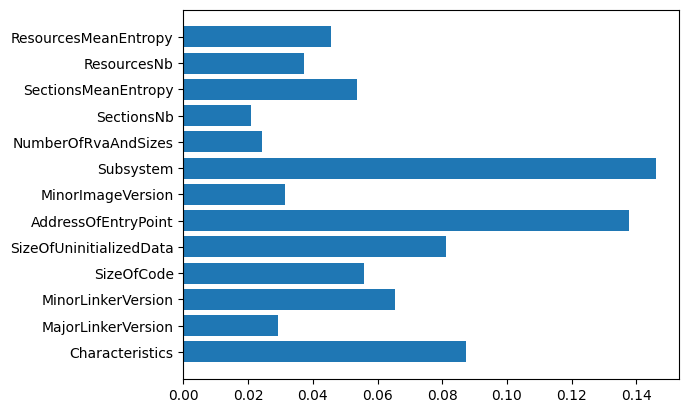

--- 0.13486480712890625 seconds ---


In [ ]:
start_time = time.time()
from matplotlib import pyplot
pyplot.barh(features,importance)
pyplot.show()
print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.2)

In [ ]:
# Importing the Keras libraries and packages
seed(1)
import tensorflow
tensorflow.random.set_seed(2)
start_time = time.time()
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from keras.layers import SimpleRNN
from keras.layers import Dropout
import keras.metrics as km

regressor = Sequential()

# Adding the first LSTM layer and some Dropout regularisation
regressor.add(LSTM(units = 10,activation='tanh', return_sequences = True, input_shape = (X_train.shape[1], 1)))

# Adding a second RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a third RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a fourth RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50,activation='tanh', return_sequences = True))
regressor.add(Dropout(0.2))

# Adding a fifth RNN layer and some Dropout regularisation
regressor.add(SimpleRNN(units = 50))
regressor.add(Dropout(0.2))

# Adding the output layer
regressor.add(Dense(units = 1))

# Compiling the RNN
regressor.compile(optimizer = 'adam', loss = 'mean_squared_error' ,metrics=['accuracy'])

# Fitting the RNN to the Training set
t = regressor.fit(X_train, y_train, epochs = 20, batch_size = 256, validation_data=(X_test,y_test))

print("--- %s seconds ---" % (time.time() - start_time))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 65s 140ms/step - accuracy: 0.8687 - loss: 0.1653 - val_accuracy: 0.9797 - val_loss: 0.0262
Epoch 2/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 66s 103ms/step - accuracy: 0.9786 - loss: 0.0343 - val_accuracy: 0.9829 - val_loss: 0.0170
Epoch 3/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 105ms/step - accuracy: 0.9836 - loss: 0.0209 - val_accuracy: 0.9842 - val_loss: 0.0146
Epoch 4/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 80s 101ms/step - accuracy: 0.9845 - loss: 0.0171 - val_accuracy: 0.9847 - val_loss: 0.0138
Epoch 5/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 46s 106ms/step - accuracy: 0.9862 - loss: 0.0150 - val_accuracy: 0.9862 - val_loss: 0.0121
Epoch 6/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 45s 104ms/step - accuracy: 0.9872 - loss: 0.0134 - val_accuracy: 0.9864 - val_loss: 0.0113
Epoch 7/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 42s 98ms/step - accuracy: 0.9872 - loss: 0.0128 - val_accuracy: 0.9879 - val_loss: 0.0106
Epoch 8/20
432/432 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step - accuracy: 0.9874 - loss: 0.0

In [ ]:
X_train.shape

(110437, 51)

In [ ]:
#Saving deep learing model in h5 format(Hierarchial Data Format)
regressor.save("classifier.h5")

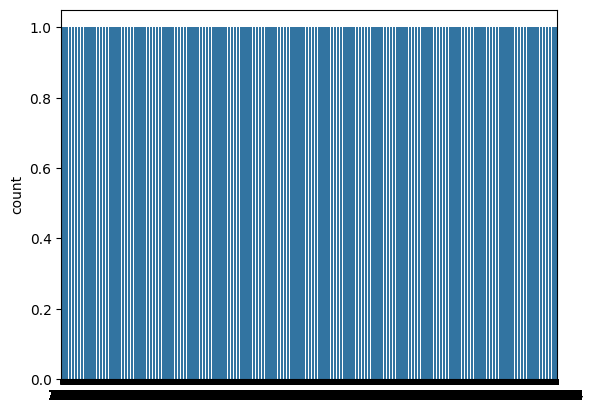

--- 698.6498072147369 seconds ---


In [ ]:
import time
start_time = time.time()
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(data["legitimate"])
plt.show()
print("--- %s seconds ---" % (time.time() - start_time))

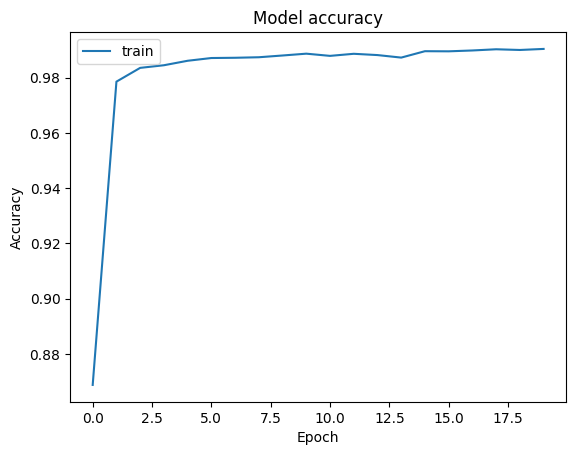

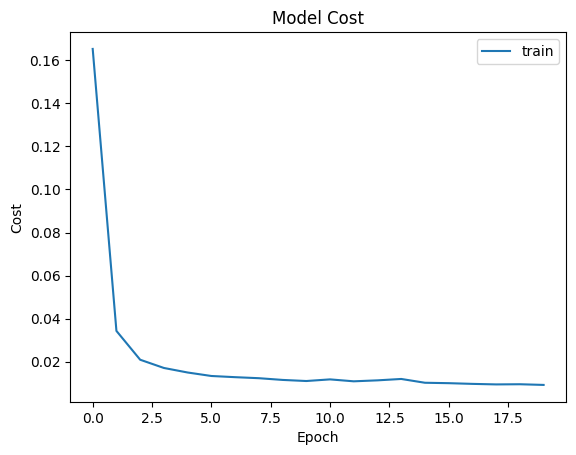

--- 0.23885512351989746 seconds ---


In [ ]:
# Visualize the result
start_time = time.time()
plt.plot(t.history['accuracy'], label='train')
plt.legend(loc='upper left')
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.show()
plt.plot(t.history['loss'], label='train')
plt.legend(loc='upper right')
plt.title('Model Cost')
plt.ylabel('Cost')
plt.xlabel('Epoch')
plt.show()
print("--- %s seconds ---" % (time.time() - start_time))

In [ ]:
start_time = time.time()
test_loss, test_accuracy = regressor.evaluate(X_test, y_test)

print('\nTest loss: {0:.6f}. Test accuracy: {1:.6f}%'.format(test_loss, test_accuracy*100.))
print("--- %s seconds ---" % (time.time() - start_time))

863/863 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9896 - loss: 0.0090

Test loss: 0.008956. Test accuracy: 98.960519%
--- 9.867746829986572 seconds ---


In [ ]:
start_time = time.time()
regressor.summary()
print("--- %s seconds ---" % (time.time() - start_time))

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 51, 10)         │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 51, 50)         │         3,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 51, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 51, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 51, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 51, 50)         │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 51, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,195 (219.52 KB)

 Trainable params: 18,731 (73.17 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 37,464 (146.35 KB)

--- 0.02194070816040039 seconds ---


In [ ]:
start_time = time.time()
predictions = regressor.predict(X_test)
d = abs(predictions.round()).astype(int)
metrics5 = evaluate_preds(y_test, d)
print("--- %s seconds ---" % (time.time() - start_time))

863/863 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step
--- 10.48853087425232 seconds ---


In [ ]:
from sklearn.metrics import classification_report

--- 0.03720855712890625 seconds ---


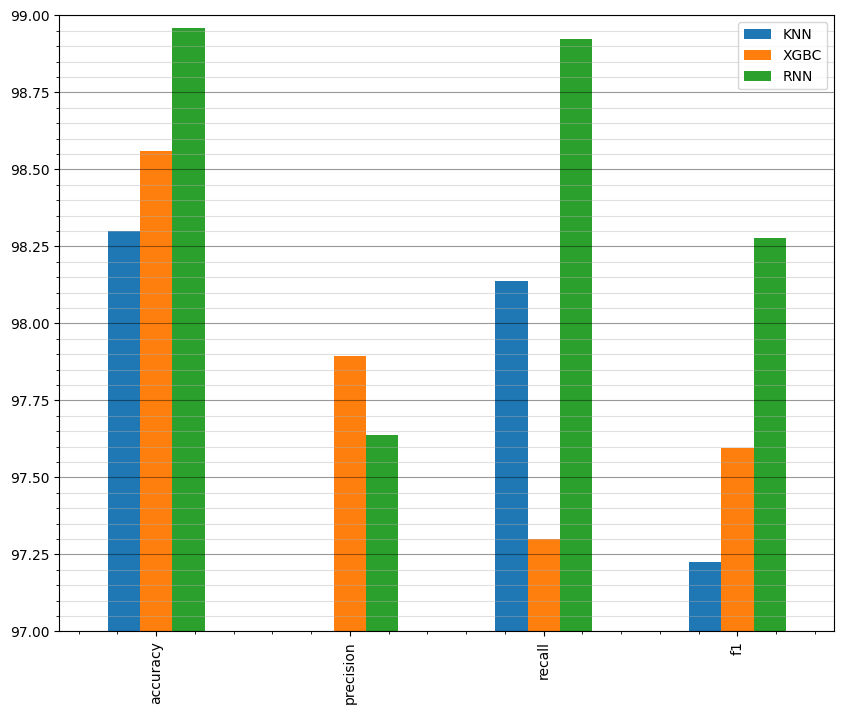

In [ ]:
start_time = time.time()
compare_metrics = pd.DataFrame({"KNN": metrics1,
                                "XGBC": metrics2,
                                "RNN" : metrics5})

compare_metrics.plot.bar(figsize=(10, 8))
plt.ylim(97,99)
plt.yscale('linear')
plt.minorticks_on()
plt.grid(axis='y',which="minor",alpha=0.4)
plt.grid(axis='y',which="major",alpha=0.4,color="black")
print("--- %s seconds ---" % (time.time() - start_time))

--- 0.053949832916259766 seconds ---


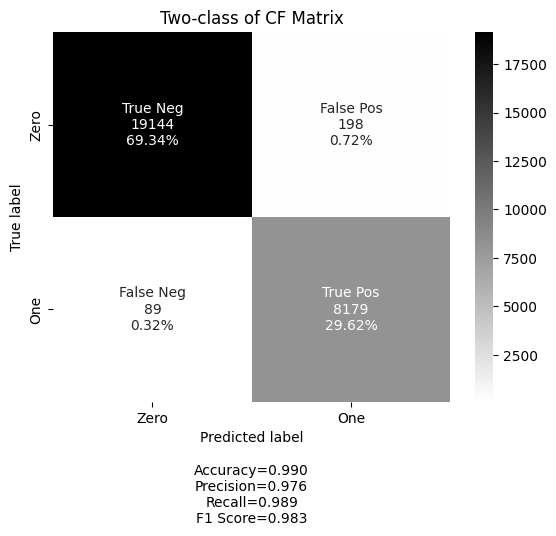

In [ ]:
start_time = time.time()
cf_matrix=confusion_matrix(y_test,d)
labels = ['True Neg','False Pos','False Neg','True Pos']
categories = ['Zero', 'One']
make_confusion_matrix(cf_matrix, group_names=labels, categories=categories, cmap='binary', title='Two-class of CF Matrix')
print("--- %s seconds ---" % (time.time() - start_time))